In [ ]:
import numpy as np
import pandas as pd

In [ ]:
from google.colab import files
files.upload()

In [ ]:
heart=pd.read_csv("index (1) (6).csv")

In [ ]:
heart.tail()

,date,datetime,cash_type,card,money,coffee_name
1128,2024-07-31,2024-07-31 20:53:35.077,card,ANON-0000-0000-0443,23.02,Cortado
1129,2024-07-31,2024-07-31 20:59:25.013,card,ANON-0000-0000-0040,27.92,Americano with Milk
1130,2024-07-31,2024-07-31 21:26:26.000,card,ANON-0000-0000-0444,32.82,Latte
1131,2024-07-31,2024-07-31 21:54:11.824,card,ANON-0000-0000-0445,32.82,Latte
1132,2024-07-31,2024-07-31 21:55:16.570,card,ANON-0000-0000-0446,32.82,Latte


In [ ]:
heart.describe(include='object')

,date,datetime,cash_type,card,coffee_name
count,1133,1133,1133,1044,1133
unique,150,1133,2,446,8
top,2024-07-30,2024-07-31 21:55:16.570,card,ANON-0000-0000-0012,Americano with Milk
freq,24,1,1044,88,268


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
heart= pd.read_csv("index (1) (6).csv")

In [ ]:
print(" First 5 rows:")
print(heart.head())

 First 5 rows:
         date                 datetime cash_type                 card  money  \
0  2024-03-01  2024-03-01 10:15:50.520      card  ANON-0000-0000-0001   38.7   
1  2024-03-01  2024-03-01 12:19:22.539      card  ANON-0000-0000-0002   38.7   
2  2024-03-01  2024-03-01 12:20:18.089      card  ANON-0000-0000-0002   38.7   
3  2024-03-01  2024-03-01 13:46:33.006      card  ANON-0000-0000-0003   28.9   
4  2024-03-01  2024-03-01 13:48:14.626      card  ANON-0000-0000-0004   38.7   

     coffee_name  
0          Latte  
1  Hot Chocolate  
2  Hot Chocolate  
3      Americano  
4          Latte  


In [ ]:
print("\n Shape of dataset (rows, columns):")
print(heart.shape)


 Shape of dataset (rows, columns):
(1133, 6)


In [ ]:

print("\n Column data types:")
print(heart.dtypes)


 Column data types:
date            object
datetime        object
cash_type       object
card            object
money          float64
coffee_name     object
dtype: object


In [ ]:
print("\n Missing values:")
print(heart.isnull().sum())



 Missing values:
date            0
datetime        0
cash_type       0
card           89
money           0
coffee_name     0
dtype: int64


In [ ]:
heart.isnull()

,date,datetime,cash_type,card,money,coffee_name
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
1128,False,False,False,False,False,False
1129,False,False,False,False,False,False
1130,False,False,False,False,False,False
1131,False,False,False,False,False,False


In [ ]:
print("\n Numerical summary:")
print(heart.describe())




 Numerical summary:
             money
count  1133.000000
mean     33.105808
std       5.035366
min      18.120000
25%      28.900000
50%      32.820000
75%      37.720000
max      40.000000


In [ ]:
print("\n Categorical summary:")
print(heart.describe(include='object'))


 Categorical summary:
              date                 datetime cash_type                 card  \
count         1133                     1133      1133                 1044   
unique         150                     1133         2                  446   
top     2024-07-30  2024-07-31 21:55:16.570      card  ANON-0000-0000-0012   
freq            24                        1      1044                   88   

                coffee_name  
count                  1133  
unique                    8  
top     Americano with Milk  
freq                    268  


In [ ]:
print("\n Duplicate rows count:")
print(heart.duplicated().sum())



 Duplicate rows count:
0


In [ ]:
print("\n Unique values:")
for col in heart.columns:
    print(f"{col}: {heart[col].nunique()}")


 Unique values:
date: 150
datetime: 1133
cash_type: 2
card: 446
money: 16
coffee_name: 8


In [ ]:
heart['datetime'] = pd.to_datetime(heart['datetime'])

In [ ]:
heart['date'] = pd.to_datetime(heart['date'])
heart['hour'] = heart['datetime'].dt.hour

In [ ]:
heart.head()

,date,datetime,cash_type,card,money,coffee_name,hour
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte,10
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate,12
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate,12
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano,13
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte,13


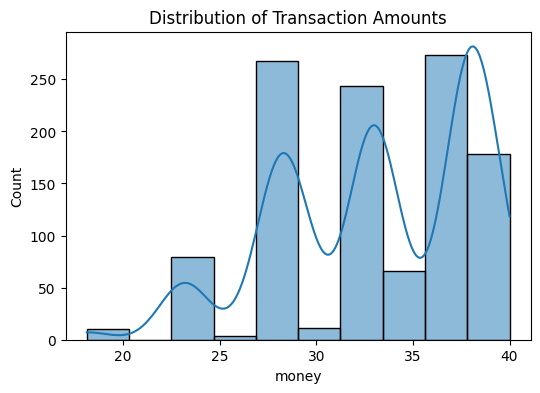

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(heart['money'], bins=10, kde=True)
plt.title('Distribution of Transaction Amounts')
plt.show()

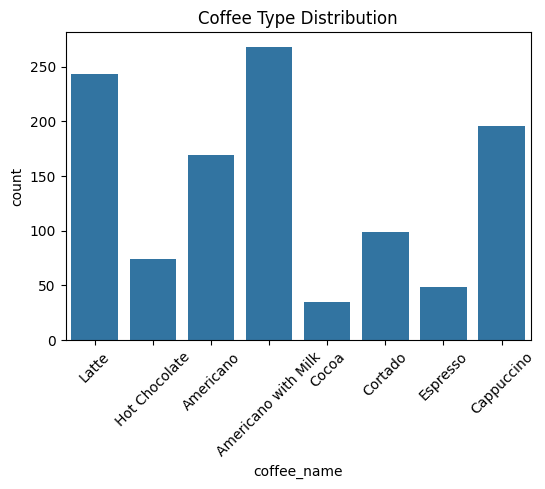

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='coffee_name', data=heart)
plt.title('Coffee Type Distribution')
plt.xticks(rotation=45)
plt.show()

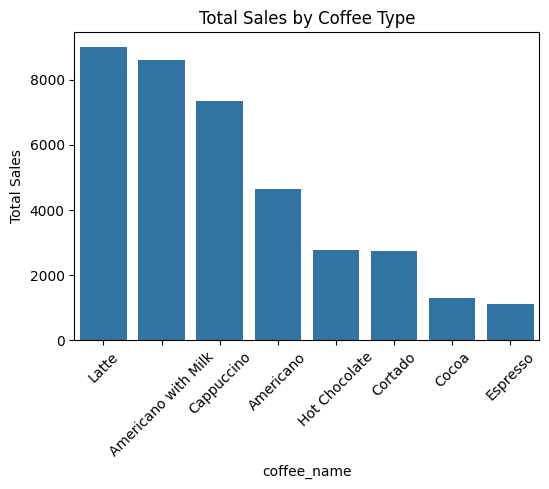

In [ ]:
sales_by_coffee = heart.groupby('coffee_name')['money'].sum().sort_values(ascending=False)
plt.figure(figsize=(6,4))
sns.barplot(x=sales_by_coffee.index, y=sales_by_coffee.values)
plt.title('Total Sales by Coffee Type')
plt.xticks(rotation=45)
plt.ylabel('Total Sales')
plt.show()

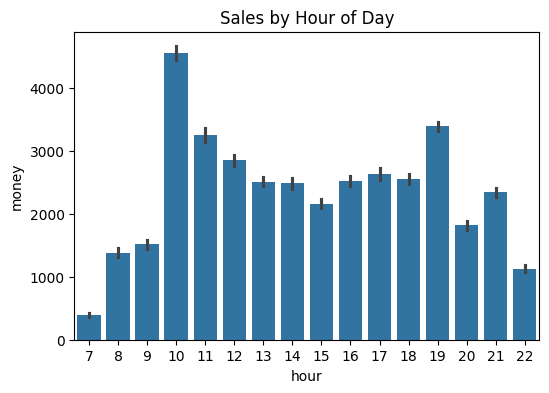

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x='hour', y='money', data=heart, estimator=sum)
plt.title('Sales by Hour of Day')
plt.show()

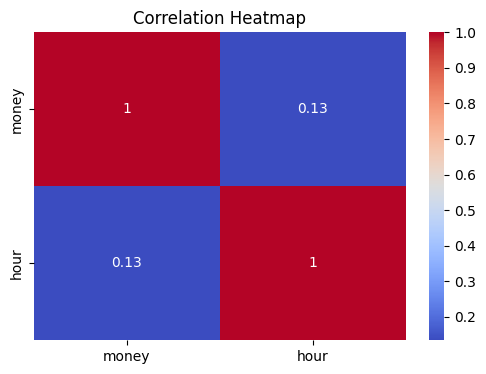

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(heart.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
sales_by_coffee = heart.groupby('coffee_name')['money'].sum().reset_index()


In [ ]:
least_sale = sales_by_coffee.sort_values(by='money', ascending=True).head(1)

In [ ]:
(" Coffee with the least total sales:")
print(least_sale)

  coffee_name    money
5    Espresso  1100.62


In [ ]:
data = {
    'date': ['2024-03-01', '2024-03-01', '2024-03-01'],
    'datetime': ['2024-03-01 10:15:50.520', '2024-03-01 12:19:22.539', '2024-03-01 12:20:18.089'],
    'cash_type': ['card', 'card', 'card'],
    'card': ['ANON-0000-0000-0001', 'ANON-0000-0000-0002', 'ANON-0000-0000-0002'],
    'money': [38.7, 38.7, 38.7],
    'coffee_name': ['Latte', 'Hot Chocolate', 'Hot Chocolate']
}


In [ ]:
sales_by_coffee = heart.groupby('coffee_name')['money'].sum().reset_index()


In [ ]:
sales_by_coffee = sales_by_coffee.sort_values(by='money', ascending=True)

In [ ]:
least_sale = sales_by_coffee.head(1)

print(" Coffee with the least total sales:")
print(least_sale)

 Coffee with the least total sales:
  coffee_name    money
5    Espresso  1100.62


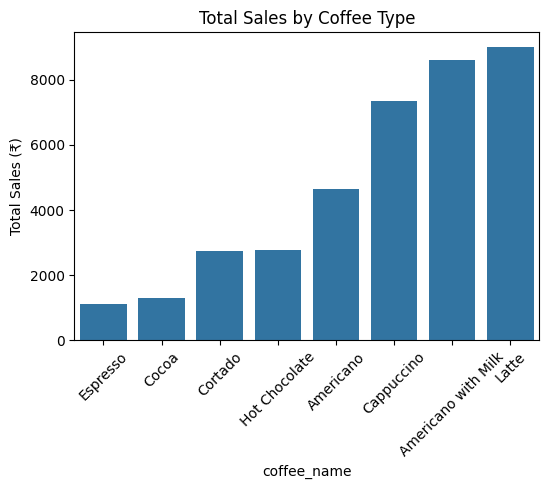

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x='coffee_name', y='money', data=sales_by_coffee)
plt.title('Total Sales by Coffee Type')
plt.xticks(rotation=45)
plt.ylabel('Total Sales (₹)')
plt.show()

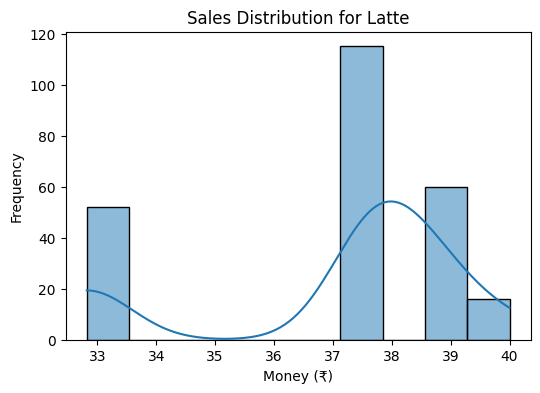

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter only Latte sales
Latte_sales = heart[heart['coffee_name'] == 'Latte']

# Plot distribution of Latte sales
plt.figure(figsize=(6,4))
sns.histplot(Latte_sales['money'], bins=10, kde=True)
plt.title('Sales Distribution for Latte')
plt.xlabel('Money (₹)')
plt.ylabel('Frequency')
plt.show()


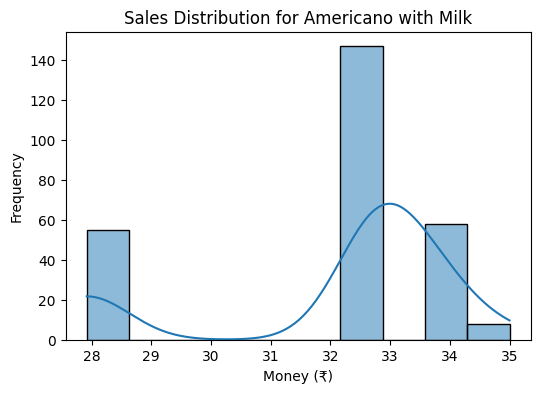

In [ ]:
# Filter only americano with milk sales
americano_with_milk_sales = heart[heart['coffee_name'] == 'Americano with Milk']

# Plot distribution of americano with milk sales
plt.figure(figsize=(6,4))
sns.histplot(americano_with_milk_sales['money'], bins=10, kde=True)
plt.title('Sales Distribution for Americano with Milk')
plt.xlabel('Money (₹)')
plt.ylabel('Frequency')
plt.show()

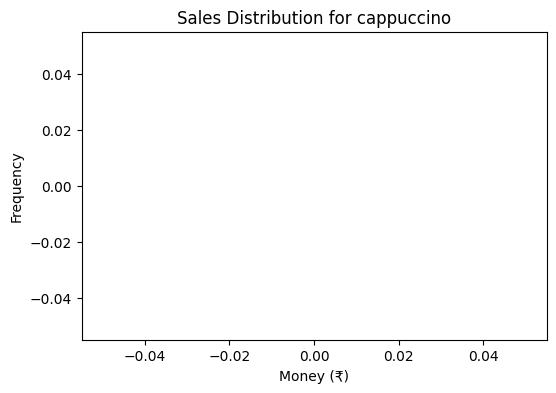

In [ ]:
# Filter only cappuccino sales
cappuccino_sales = heart[heart['coffee_name'] == 'cappuccino']

# Plot distribution of cappuccino sales
plt.figure(figsize=(6,4))
sns.histplot(cappuccino_sales['money'], bins=10, kde=True)
plt.title('Sales Distribution for cappuccino')
plt.xlabel('Money (₹)')
plt.ylabel('Frequency')
plt.show()

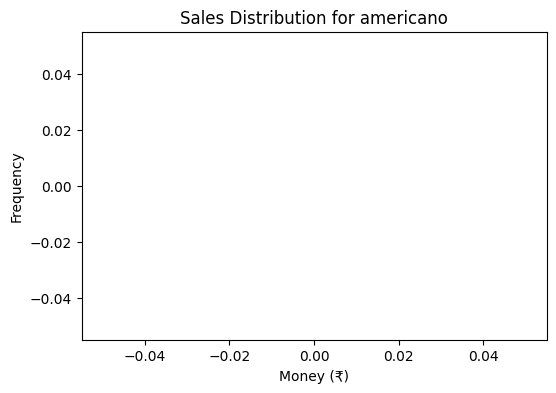

In [ ]:
# Filter only americano sales
americano_sales = heart[heart['coffee_name'] == 'americano']
# Plot distribution of americano sales
plt.figure(figsize=(6,4))
sns.histplot(americano_sales['money'], bins=10, kde=True)
plt.title('Sales Distribution for americano')
plt.xlabel('Money (₹)')
plt.ylabel('Frequency')
plt.show()

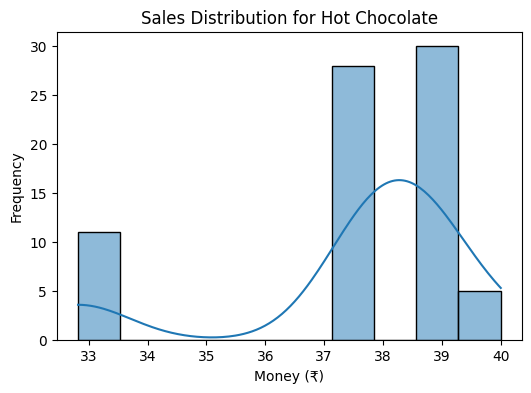

In [ ]:
# Filter only hot chocolate sales
hot_chocolate_sales = heart[heart['coffee_name'] == 'Hot Chocolate']
# Plot distribution of hot chocolate sales
plt.figure(figsize=(6,4))
sns.histplot(hot_chocolate_sales['money'], bins=10, kde=True)
plt.title('Sales Distribution for Hot Chocolate')
plt.xlabel('Money (₹)')
plt.ylabel('Frequency')
plt.show()

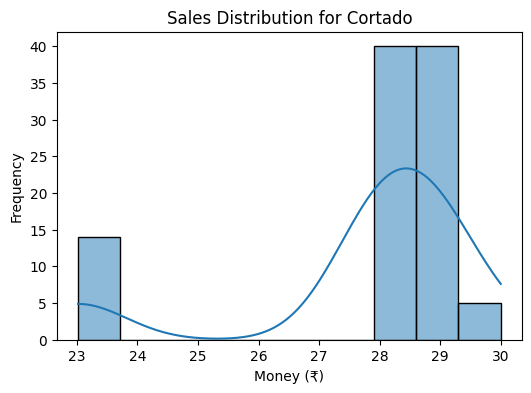

In [ ]:
# Filter only cortado sales
cortado_sales = heart[heart['coffee_name'] == 'Cortado']
# Plot distribution of hot chocolate sales
plt.figure(figsize=(6,4))
sns.histplot(cortado_sales['money'], bins=10, kde=True)
plt.title('Sales Distribution for Cortado')
plt.xlabel('Money (₹)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Filter only cocoa sales
cocoa_sales = heart[heart['coffee_name'] == 'Cocoa']

# Plot distribution of Cocoa sales
plt.figure(figsize=(6,4))
sns.histplot(Cocoa_sales['money'], bins=10, kde=True)
plt.title('Sales Distribution for Cocoa')
plt.xlabel('Money (₹)')
plt.ylabel('Frequency')
plt.show()

NameError: name 'Cocoa_sales' is not defined

<Figure size 600x400 with 0 Axes>

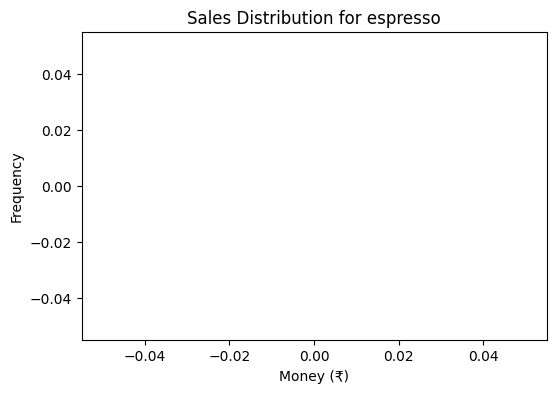

In [ ]:
# Filter only espresso sales
espresso_sales = heart[heart['coffee_name'] == 'espresso']

# Plot distribution of espresso sales
plt.figure(figsize=(6,4))
sns.histplot(espresso_sales['money'], bins=10, kde=True)
plt.title('Sales Distribution for espresso')
plt.xlabel('Money (₹)')
plt.ylabel('Frequency')
plt.show()

In [ ]:

espresso_sales = heart[heart['coffee_name'] == 'espresso']
espresso_sales

,date,datetime,cash_type,card,money,coffee_name,hour


In [ ]:
heart['coffee_name'].value_counts()

,count
coffee_name,
Americano with Milk,268
Latte,243
Cappuccino,196
Americano,169
Cortado,99
Hot Chocolate,74
Espresso,49
Cocoa,35
